In [42]:
# Importing libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Load your data into Jupyter Notebook.

In [43]:
icuData = pd.read_excel("G:/Meu Drive/_INTERCAMBIO/6. ESCOLA E EXAMES/COLLEGE/KARINA/CITY COLLEGE/01. Statistics for Data Analytics/Week 10 - Final Project/Github - Statistics_for_Data_Analytics_Final_Project/data/MIMIC II Surgical Intensive Care Unit Data.xlsx")
icuData

,aline_flg,icu_los_day,hospital_los_day,age,gender_num,weight_first,bmi,sapsi_first,sofa_first,service_unit,...,platelet_first,sodium_first,potassium_first,tco2_first,chloride_first,bun_first,creatinine_first,po2_first,pco2_first,iv_day_1
0,1,7.63,13,72.36841,1,75.0,29.912791,15,9,SICU,...,354,138,4.6,15.0,109,41,1.6,196,39,2230.875000
1,1,0.58,3,44.49191,0,0.0,0.000000,21,7,SICU,...,262,139,4.2,31.0,100,16,0.5,146,23,0.000000
2,1,1.75,5,23.74217,1,95.2,28.464563,18,7,SICU,...,22,146,3.4,19.0,110,10,1.0,134,30,2358.244141
3,0,1.38,9,36.54657,1,72.0,23.982402,14,5,SICU,...,182,145,3.6,26.0,110,10,0.7,0,0,1877.560059
4,1,7.06,27,24.64717,1,90.0,25.474850,15,6,SICU,...,130,143,3.8,32.0,104,17,1.3,38,62,648.599976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,0,2.27,2,50.15744,0,0.0,0.000000,14,7,SICU,...,159,139,4.0,22.0,103,22,1.2,144,36,650.000000
978,0,1.08,3,77.96057,0,0.0,0.000000,16,5,SICU,...,312,142,3.3,24.0,107,16,0.8,0,0,150.000000
979,0,2.45,3,33.04643,1,84.0,0.000000,16,6,SICU,...,177,138,3.7,15.0,113,15,1.2,158,45,1836.659912
980,1,3.70,4,72.44020,0,60.0,0.000000,14,5,SICU,...,363,138,6.3,22.0,104,20,0.8,154,45,289.950012


In [44]:
# Main values of the dataset
icuData.describe()

,aline_flg,icu_los_day,hospital_los_day,age,gender_num,weight_first,bmi,sapsi_first,sofa_first,service_num,...,platelet_first,sodium_first,potassium_first,tco2_first,chloride_first,bun_first,creatinine_first,po2_first,pco2_first,iv_day_1
count,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.0,...,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000
mean,0.706721,3.534155,9.007128,53.144155,0.618126,75.667546,18.620344,13.628310,5.827902,1.0,...,244.015275,139.598778,4.000611,24.018228,104.328921,16.809572,0.996741,221.572301,36.917515,1624.942100
std,0.455497,3.669347,8.837931,21.407871,0.486093,26.059355,13.557910,4.957858,2.182760,0.0,...,91.448301,7.467355,0.746135,4.205075,7.021357,9.826600,0.693166,153.155829,14.891737,1654.865304
min,0.000000,0.500000,1.000000,15.190460,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.412500,4.000000,35.547540,0.000000,64.150000,0.000000,11.000000,4.000000,1.0,...,185.000000,138.000000,3.600000,22.000000,101.000000,11.000000,0.700000,104.250000,34.000000,260.329155
50%,1.000000,2.295000,7.000000,52.277470,1.000000,76.900000,22.898715,14.000000,6.000000,1.0,...,237.000000,140.000000,3.900000,24.000000,105.000000,15.000000,0.900000,198.000000,39.000000,1134.629944
75%,1.000000,4.095000,11.000000,72.525320,1.000000,89.000000,28.206258,17.000000,7.000000,1.0,...,295.750000,142.000000,4.300000,27.000000,107.000000,20.000000,1.100000,325.750000,44.000000,2573.405883
max,1.000000,28.240000,112.000000,96.454240,1.000000,211.000000,53.174533,32.000000,16.000000,1.0,...,681.000000,157.000000,9.200000,40.000000,133.000000,139.000000,9.400000,634.000000,89.000000,10360.624020


### 2. Create pairwise scatterplots of variables of interest. Describe your discoveries and the relationships, if any.

#### Plotting pairwise scatterplots of variables of interest

In [45]:
# Variables of interest
icuData_columns = icuData[['icu_los_day', 'hospital_los_day', 'age', 'gender_num', 'bmi', 'icu_exp_flg', 'map_1st', 'hr_1st', 'temp_1st', 'abg_count']]

In [46]:
# Understanting the correlations
icuData_corr = icuData_columns.corr()
icuData_corr

,icu_los_day,hospital_los_day,age,gender_num,bmi,icu_exp_flg,map_1st,hr_1st,temp_1st,abg_count
icu_los_day,1.000000,0.541014,0.134810,-0.007259,0.087458,0.037265,0.024100,0.006363,0.018844,0.763337
hospital_los_day,0.541014,1.000000,0.043880,0.025311,0.108622,-0.172200,-0.023788,0.087169,0.040175,0.449319
age,0.134810,0.043880,1.000000,-0.254878,-0.006805,0.351284,0.063527,-0.304370,-0.028704,0.063781
gender_num,-0.007259,0.025311,-0.254878,1.000000,0.045374,-0.103387,0.035913,0.073499,0.069135,0.040110
bmi,0.087458,0.108622,-0.006805,0.045374,1.000000,-0.028789,0.030342,0.063394,0.051216,0.161522
icu_exp_flg,0.037265,-0.172200,0.351284,-0.103387,-0.028789,1.000000,0.055396,-0.055879,-0.042697,0.051689
map_1st,0.024100,-0.023788,0.063527,0.035913,0.030342,0.055396,1.000000,0.081121,0.018905,-0.004030
hr_1st,0.006363,0.087169,-0.304370,0.073499,0.063394,-0.055879,0.081121,1.000000,0.056076,0.072391
temp_1st,0.018844,0.040175,-0.028704,0.069135,0.051216,-0.042697,0.018905,0.056076,1.000000,0.002002
abg_count,0.763337,0.449319,0.063781,0.040110,0.161522,0.051689,-0.004030,0.072391,0.002002,1.000000


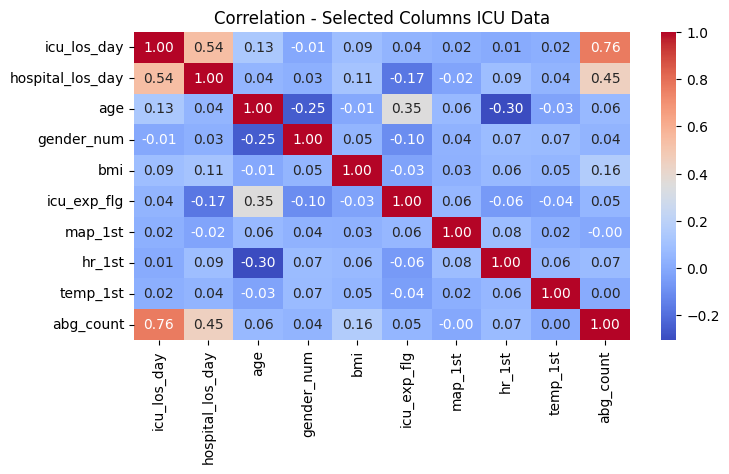

In [47]:
# Heatmap of the correlations
plt.figure(figsize=(8, 4))
sns.heatmap(icuData_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation - Selected Columns ICU Data")
plt.savefig("../images/correlation_heatmap.png", bbox_inches="tight")
plt.show()

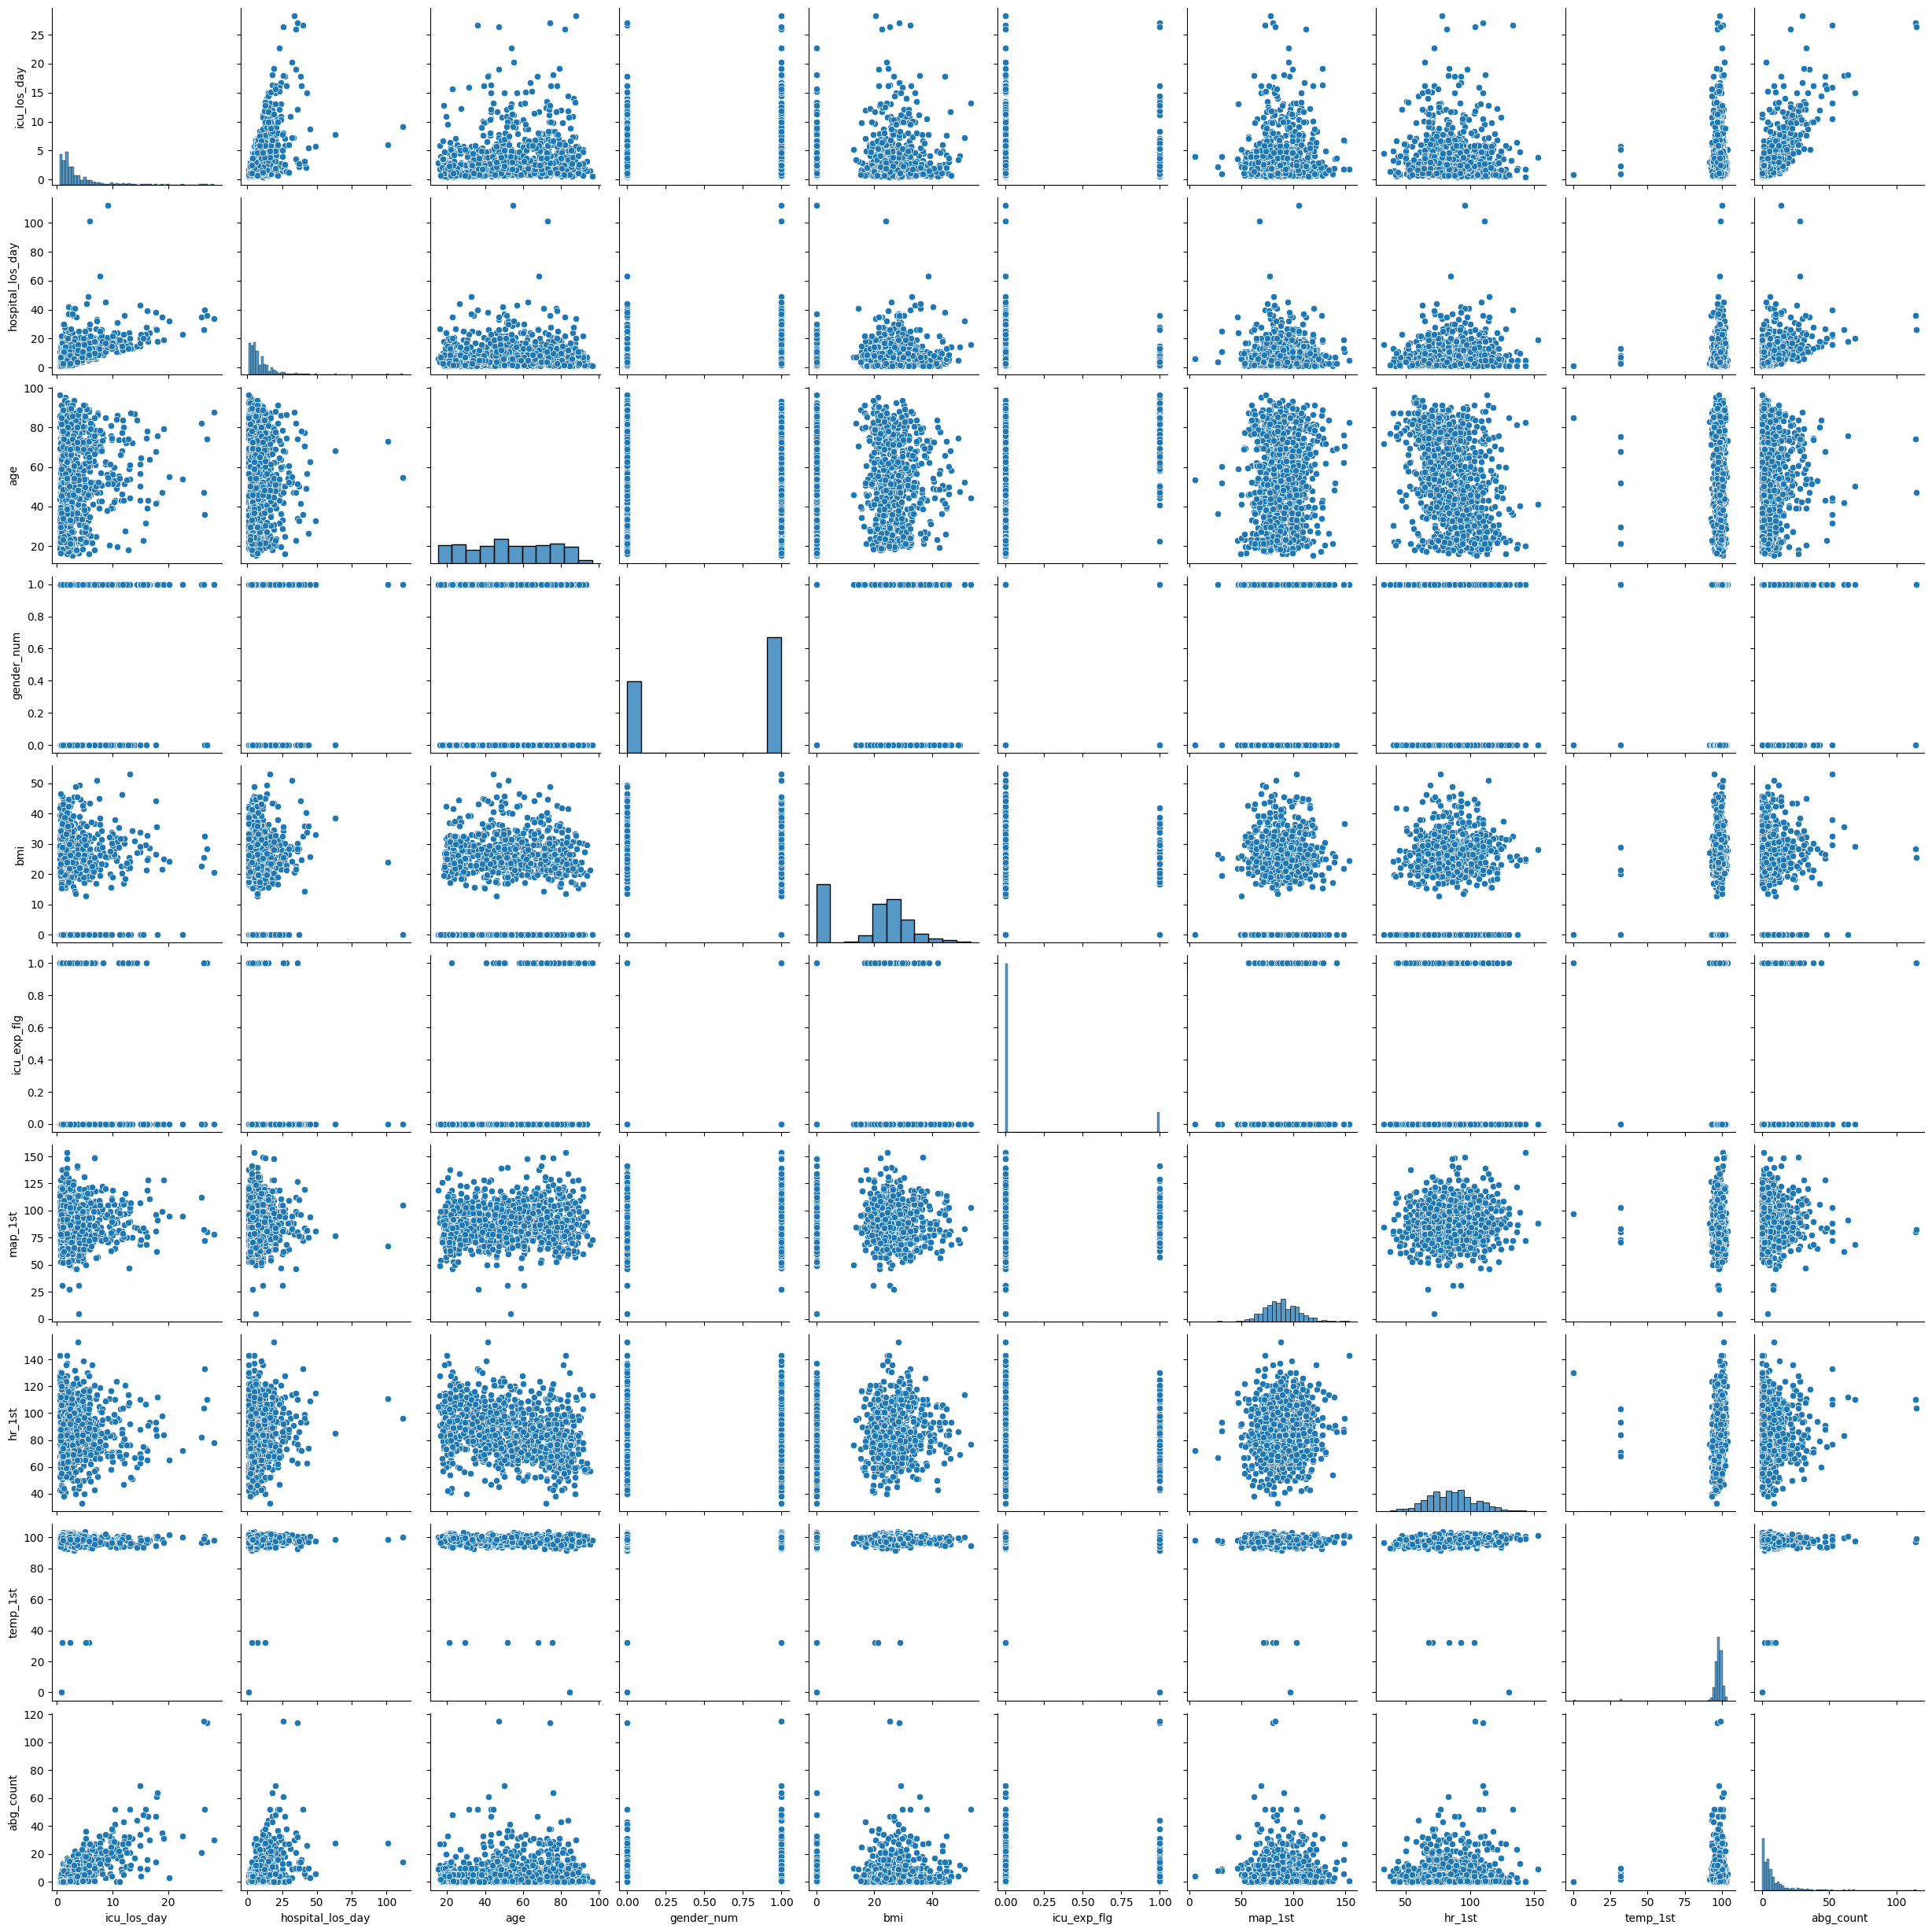

In [48]:
sns.pairplot(icuData_columns)
plt.show()

### 3. Create box plots to identify outliers.

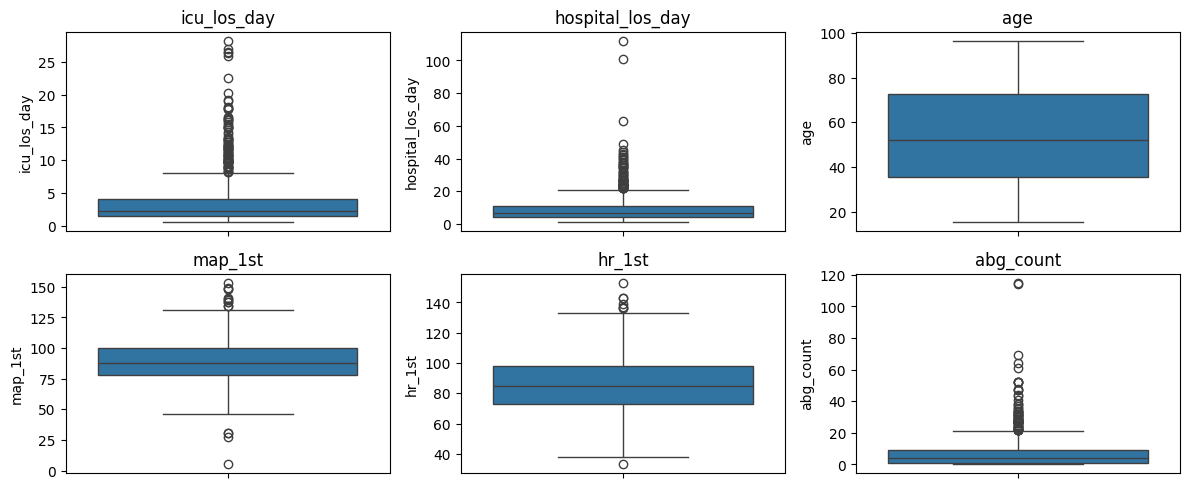

In [49]:
# Selected variables to analyse
icuData_selection = icuData[['icu_los_day', 'hospital_los_day', 'age', 'map_1st', 'hr_1st', 'abg_count']]

# Visualising the boxplots
fig = plt.figure(figsize=(12,5))
for i, var in enumerate(icuData_selection, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=var, data=icuData)
    plt.title(var)
plt.tight_layout()
plt.show()

### 4. Perform data cleaning and preprocessing, this might include data amputation of the extreme variables.

In [50]:
Initial_Null_Value = icuData.isnull().sum().sum()

icuData.loc[icuData['icu_los_day'] > 12, 'icu_los_day'] = np.nan
icuData.loc[icuData['hospital_los_day'] > 30, 'hospital_los_day'] = np.nan
icuData.loc[(icuData['map_1st'] > 130) | (icuData['map_1st'] < 30), 'map_1st'] = np.nan
icuData.loc[icuData['hr_1st'] > 140, 'hr_1st'] = np.nan
icuData.loc[icuData['abg_count'] > 30, 'abg_count'] = np.nan

Final_Null_Value = icuData.isnull().sum().sum()

print('These are the observations removed: ' + str(Final_Null_Value - Initial_Null_Value))
print('These are the observations that conform to outliers: ' + str(round((Final_Null_Value - Initial_Null_Value) * 100 / icuData.shape[0], 2)) + '%')

These are the observations removed: 116
These are the observations that conform to outliers: 11.81%


### 5. Conduct data analysis: calculate the median, mean, and standard deviation of variables of interest. Discuss the implications of the results.

In [51]:
icuData[['icu_los_day', 'hospital_los_day', 'age', 'map_1st', 'hr_1st', 'abg_count']].describe()

,icu_los_day,hospital_los_day,age,map_1st,hr_1st,abg_count
count,941.000000,956.000000,982.000000,967.000000,979.000000,951.000000
mean,2.963369,8.052301,53.144155,88.250949,85.574055,5.851735
std,2.314008,5.978617,21.407871,15.878529,17.971500,6.175511
min,0.500000,1.000000,15.190460,31.000000,33.000000,0.000000
25%,1.360000,4.000000,35.547540,77.333298,73.000000,1.000000
50%,2.170000,6.000000,52.277470,88.000000,85.000000,4.000000
75%,3.830000,11.000000,72.525320,99.000000,97.000000,8.000000
max,11.960000,30.000000,96.454240,130.000000,139.000000,30.000000


### 6. Create new box plots after data imputation and analyse the results.

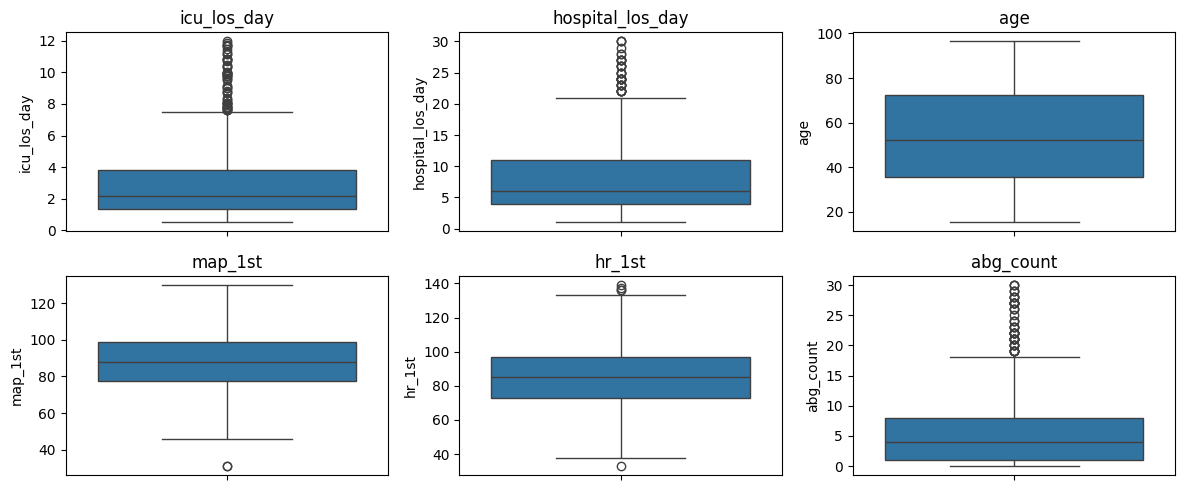

In [52]:
fig = plt.figure(figsize=(12,5))
for i, var in enumerate(icuData_selection, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=var, data=icuData)
    plt.title(var)
plt.tight_layout()
plt.savefig("../images/box_plot.png", bbox_inches="tight")
plt.show()

### 7. Explain the concept of multicollinearity in the context of the dataset. Apply PCA and visualize Principal Component 1 and Principal Component 2.

In [53]:
icuData2 = icuData_selection.dropna()

In [54]:
# Standardizing the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
icuData_scaled = scaler.fit_transform(icuData2)

In [55]:
# Applying PCA
from sklearn.decomposition import PCA
target_variable = icuData['icu_exp_flg']

pca = PCA(n_components=2)
icuData_pca = pca.fit_transform(icuData_scaled)
print("Shape of the data after PCA:", icuData_pca.shape)

# Creating a DataFrame for the principal components
icuData_pca_df = pd.DataFrame(data=icuData_pca, columns=['Principal Component 1', 'Principal Component 2'])
icuData_pca_df[target_variable] = target_variable.values

Shape of the data after PCA: (982, 2)


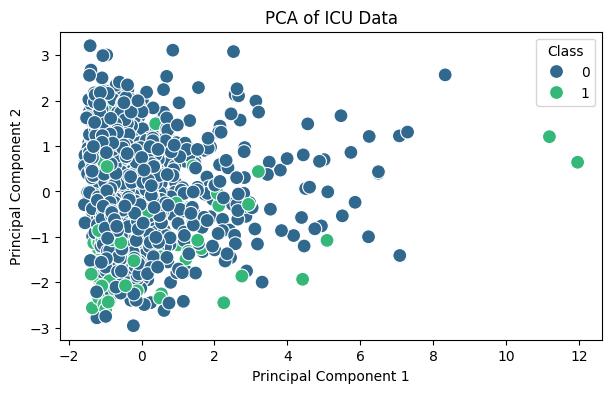

In [56]:
# Visualizing Principal Component 1 and Principal Component 2 using a scatter plot
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue=target_variable, data=icuData_pca_df, palette='viridis', s=100)
plt.title('PCA of ICU Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class')
plt.savefig("../images/PCA_ICU_data.png", bbox_inches="tight")
plt.show()

### 8. Using Logistic Regression

#### In the SICU dataset given, your target variable is icu exp flg, which is the ICU Mortality.
#### Separate the variable icu exp flg from the main dataset to create two distinct datasets: one containing all independent variables (X) and another containing only the target variable (y). This process ensures that the dataset for X includes data for all features excluding icu exp flg, while the dataset for y exclusively holds the values of the target variable icu exp flg.

In [58]:
# Separate the target variable (ICU Mortality) from the main dataset
X = icuData.drop(columns=['icu_exp_flg'])
y = icuData['icu_exp_flg']

# Encoding Categorical Variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_columns = ['service_unit', 'day_icu_intime']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ct = ColumnTransformer(transformers=[('encoder', ohe, categorical_columns)], remainder='passthrough')

# Apply the ColumnTransformer
X_encoded = ct.fit_transform(X)

# Get feature names after one-hot encoding
feature_names = ct.get_feature_names_out()

# Create a DataFrame for the encoded variables
X = pd.DataFrame(X_encoded, columns=feature_names)

In [59]:
# Fill missing values in the dataset
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=feature_names)

#### After doing this, Split your dataset into train and test data.

In [60]:
# Split the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Normalize the data using StandardScaler.

In [61]:
# Normalization using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Create and train a logistic regression model.

In [62]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Make predictions on the test set and Evaluate the performance of the logistic regression model.

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make Predictions on the Test Set
y_pred = logistic_model.predict(X_test_scaled)

# Evaluate the Performance of the Logistic Regression Model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

#### Print the Accuracy and Confusion Matrix.

In [64]:
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.9644670050761421
Confusion Matrix:
 [[174   4]
 [  3  16]]


#### Visualize your confusion matrix

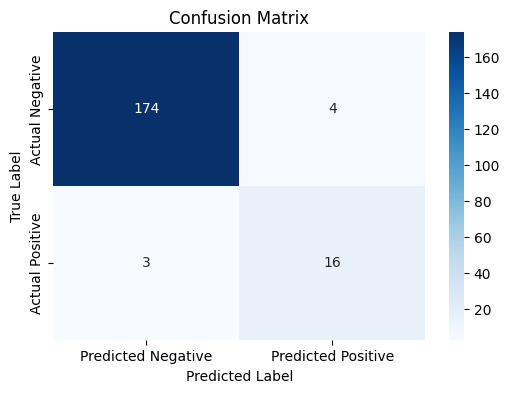

In [65]:
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig("../images/confusion matrix.png", bbox_inches="tight")
plt.show()